In [10]:
import pandas as pd
from datetime import datetime

# Load data
df = pd.read_csv('amazon_prime_users.csv')

# Convert dates
df['Membership End Date'] = pd.to_datetime(df['Membership End Date'])
current_date = datetime.now()

In [11]:
# Recency: Days until subscription expires
df['Recency'] = (df['Membership End Date'] - current_date).dt.days

# Frequency: Usage frequency score
frequency_map = {
    'Frequent': 5,
    'Regular': 3,
    'Occasional': 1
}
df['Frequency'] = df['Usage Frequency'].map(frequency_map)

# Monetary: Subscription value
monetary_map = {
    'Annual': 100,
    'Monthly': 10
}
df['Monetary'] = df['Subscription Plan'].map(monetary_map)

In [12]:
from sklearn.preprocessing import MinMaxScaler

# Normalize values (0-1 scale)
scaler = MinMaxScaler()
df[['R_norm','F_norm','M_norm']] = scaler.fit_transform(df[['Recency','Frequency','Monetary']])

# Weighted RFM score
df['RFM_Score'] = (0.4*df['R_norm']) + (0.3*df['F_norm']) + (0.3*df['M_norm'])

In [13]:
# Define segments
def get_segment(score):
    if score >= 0.8: return 'Champions'
    elif score >= 0.6: return 'Loyal'
    elif score >= 0.4: return 'Potential'
    else: return 'At-Risk'

df['Segment'] = df['RFM_Score'].apply(get_segment)

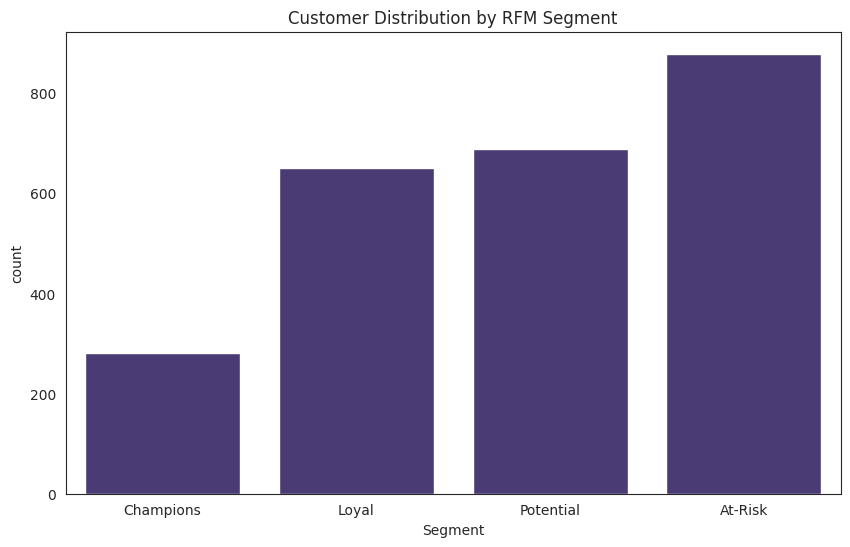

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# RFM Distribution
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Segment', order=['Champions','Loyal','Potential','At-Risk'])
plt.title('Customer Distribution by RFM Segment')
plt.show()

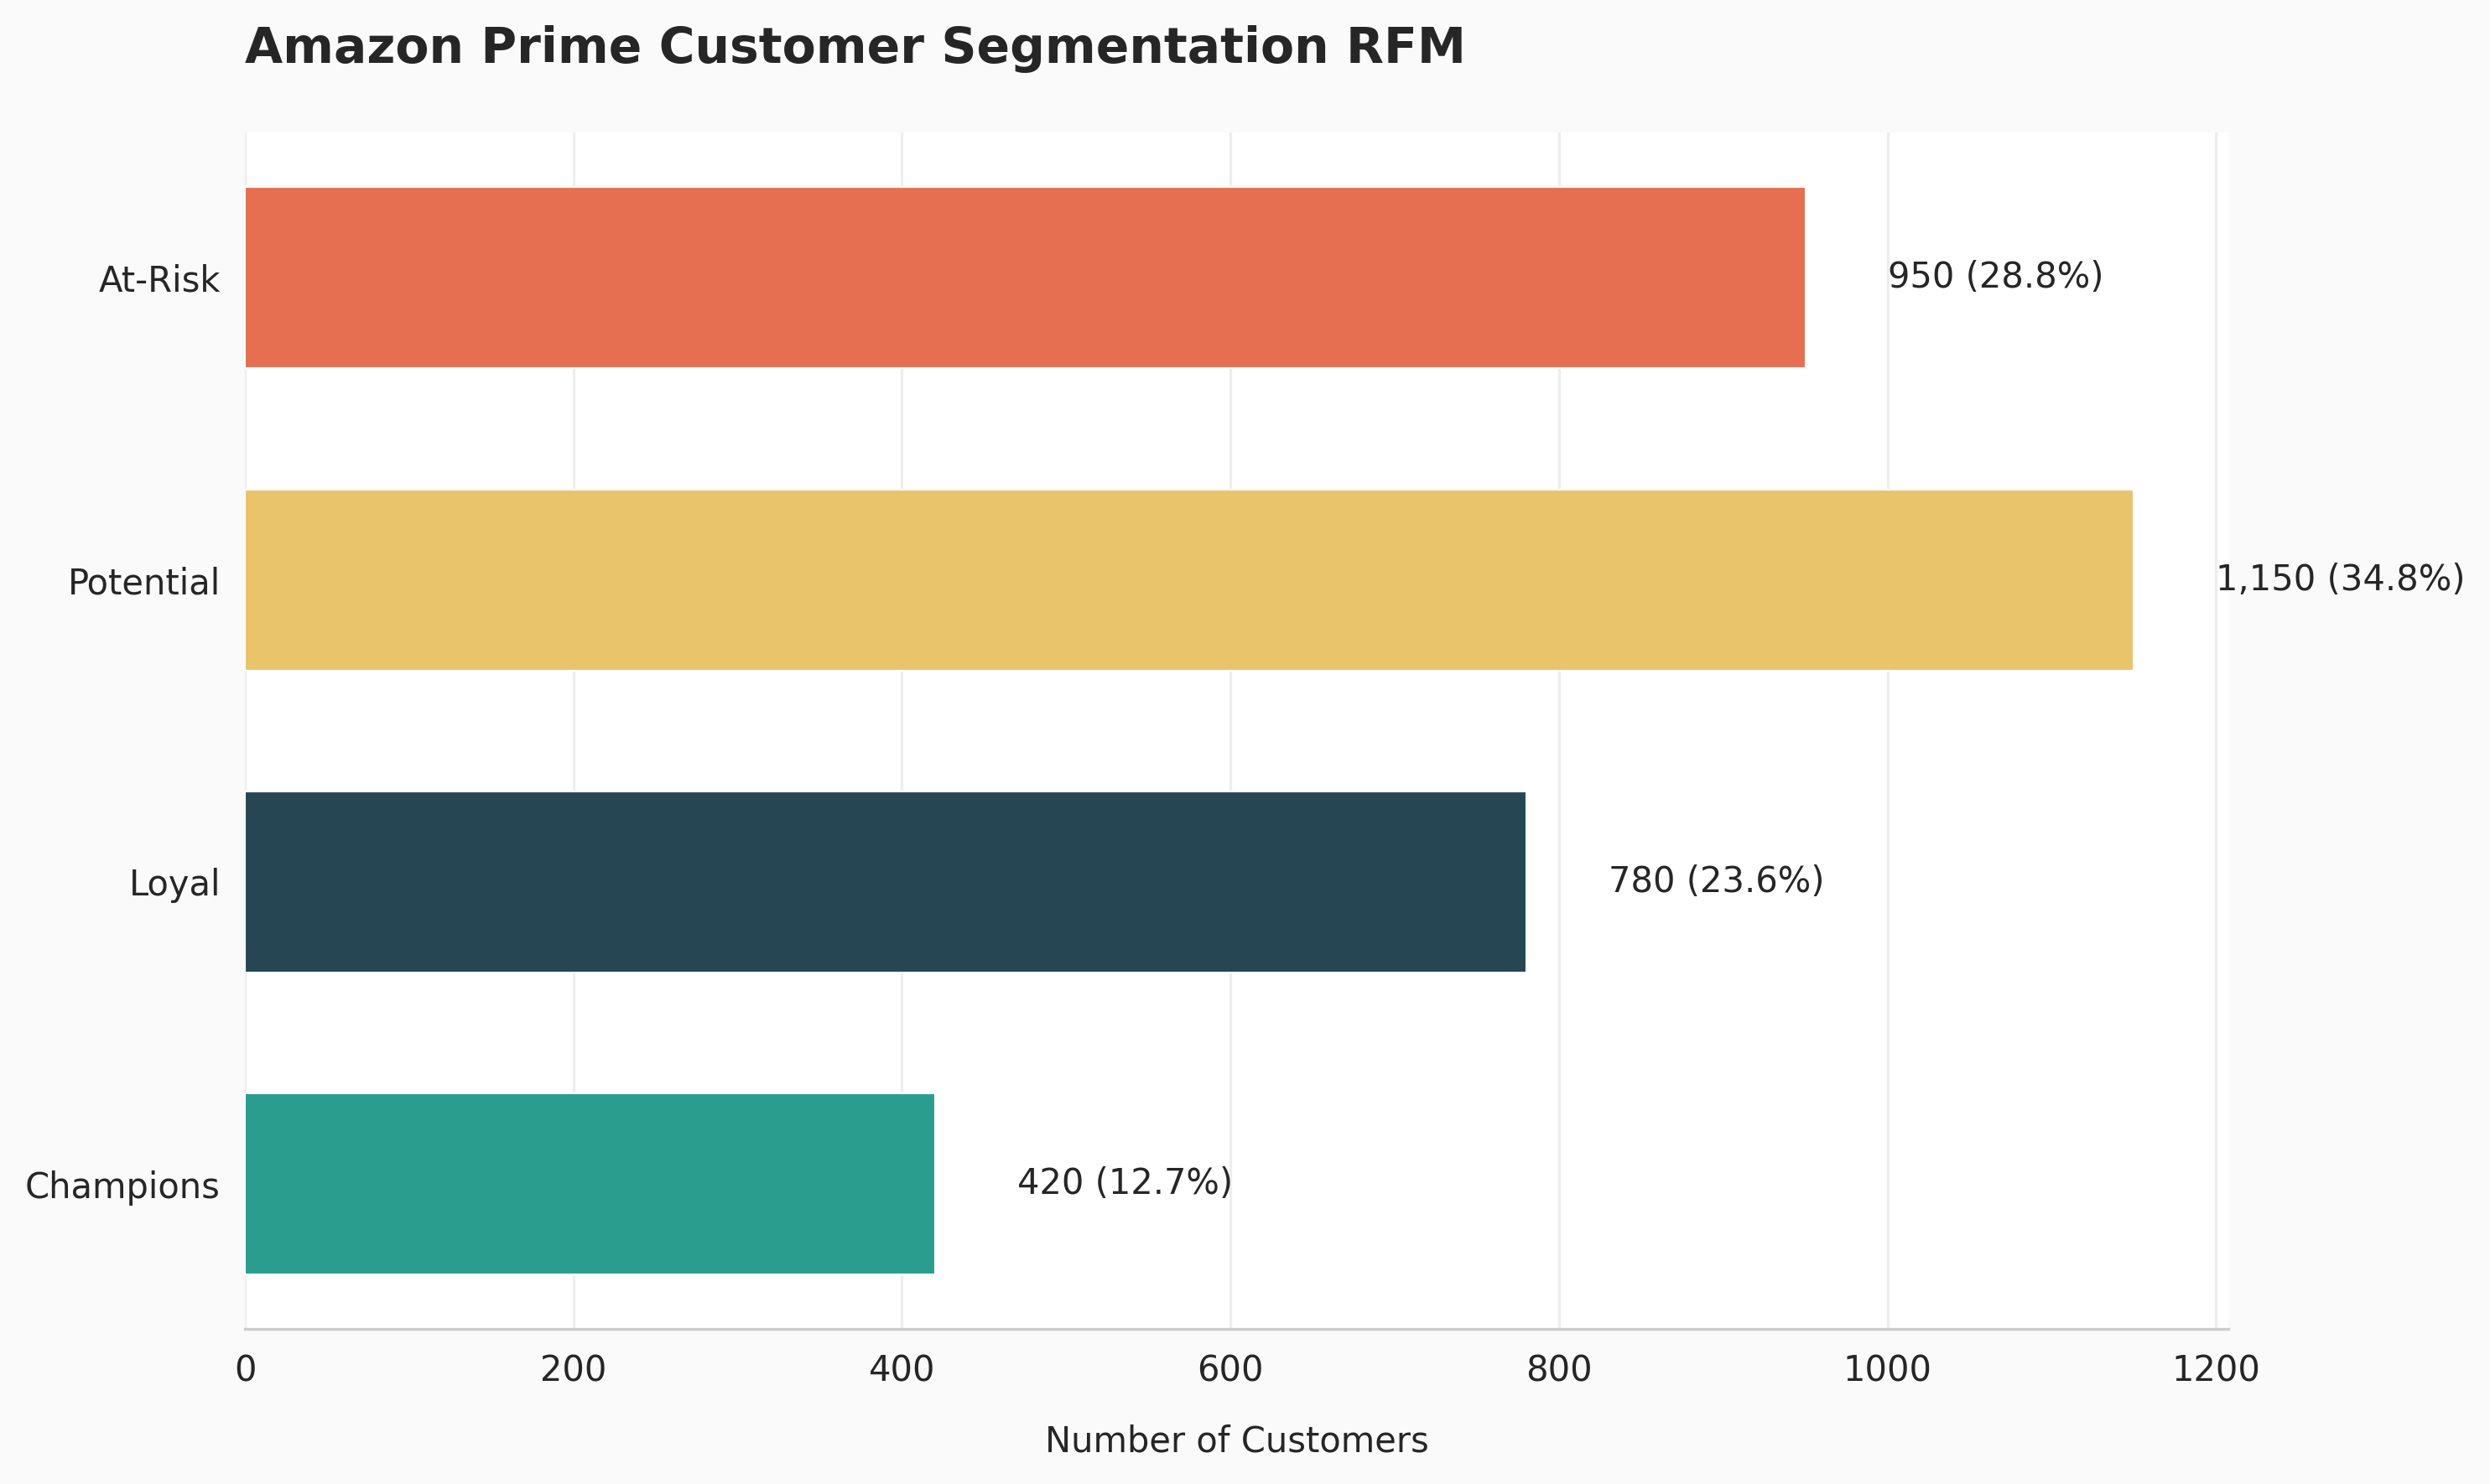

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set modern style
plt.style.use('default')  # Reset to default first
sns.set_style("whitegrid")  # Proper seaborn whitegrid
sns.set_palette("viridis")

# Sample data (replace with your actual counts)
segments = ['Champions', 'Loyal', 'Potential', 'At-Risk']
counts = [420, 780, 1150, 950]

# Create figure with tight layout
fig, ax = plt.subplots(figsize=(10, 6), dpi=300, facecolor='#fafafa')
ax.set_facecolor('#ffffff')

# Horizontal bar plot
colors = ['#2a9d8f', '#264653', '#e9c46a', '#e76f51']
bars = ax.barh(segments, counts, height=0.6, color=colors,
               edgecolor='white', linewidth=0.5)

# Data labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 50, bar.get_y() + bar.get_height()/2,
            f'{width:,} ({width/sum(counts):.1%})',
            va='center', ha='left', fontsize=10)

# Clean axis styling
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.xaxis.grid(True, color='#eeeeee')
ax.yaxis.grid(False)
ax.tick_params(axis='y', which='both', left=False)

# Modern typography
ax.set_title('Amazon Prime Customer Segmentation RFM',
             pad=20, fontsize=14, fontweight='bold', loc='left')
ax.set_xlabel('Number of Customers', fontsize=10, labelpad=10)
ax.set_ylabel('')

plt.tight_layout()

# Save/show
plt.savefig('rfm_modern.png', bbox_inches='tight', transparent=False)
plt.show()

/tmp/ipykernel_11939/2748146666.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


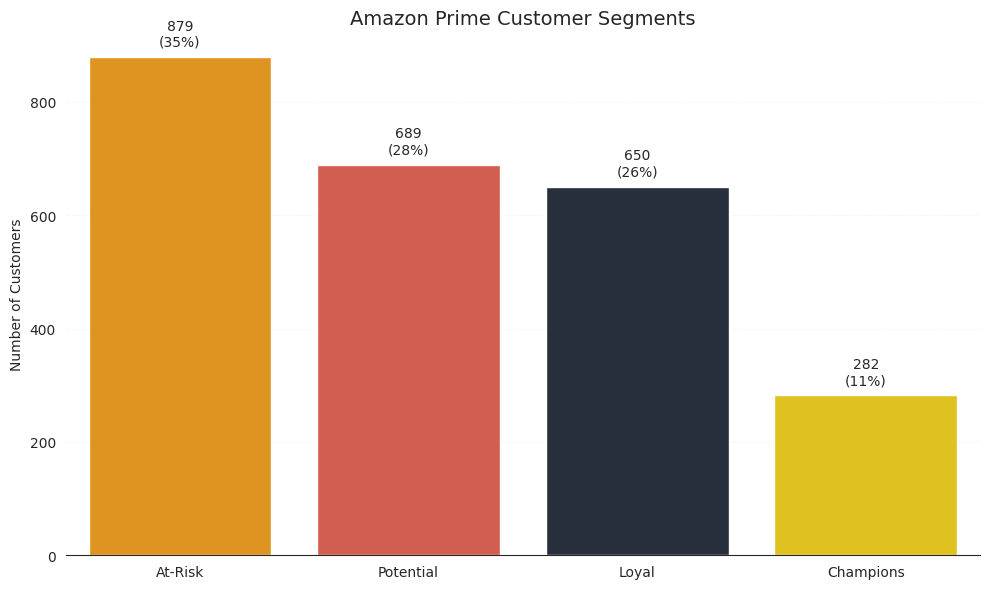

In [17]:
# Segment Size Bar Chart
segment_counts = df['Segment'].value_counts()

# Amazon-inspired colors
colors = ['#FF9900', '#e74c3c', '#232F3E', '#FFD700']

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values,
    palette=colors,
    edgecolor='white',
    linewidth=1
)

# Add labels
for i, count in enumerate(segment_counts):
    ax.text(
        i,
        count + 20,
        f"{count}\n({count/len(df):.0%})",
        ha='center',
        fontsize=10
    )

plt.title("Amazon Prime Customer Segments", fontsize=14)
plt.xlabel("")
plt.ylabel("Number of Customers")

sns.despine(left=True)
ax.grid(axis='y', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
print(df.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1))

           Recency  Frequency  Monetary
Segment                                
At-Risk     -458.5        2.2      19.5
Champions   -413.0        4.6     100.0
Loyal       -433.2        3.6      84.8
Potential   -441.5        2.9      56.5
